In [1]:
import polars as pl 
import seaborn as sns
import matplotlib.pyplot as plt 
from dbconfig import engine
print('Environment ready!')

Environment ready!


In [2]:
from pathlib import Path 

plots_dir = Path('plots')
plots_dir.mkdir(exist_ok = True)

In [3]:
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_float_precision(2)
pl.Config.set_thousands_separator(",")

polars.config.Config

In [59]:
revenue_df = pl.read_database(
        query = """
        select seller_id,
        sum(price) as revenue,
        count(distinct order_id) as orders,
        count(*) as items_sold,
        avg(price) as average_price,
        round(sum(price)::numeric/count(distinct order_id),2) as average_order_value
        from clean.order_items
        group by seller_id;
        """, connection = engine
        )

In [60]:
revenue_df.sort('revenue', descending = True).head()

seller_id,revenue,orders,items_sold,average_price,average_order_value
str,f64,i64,i64,f64,"decimal[38,2]"
"""4869f7a5dfa277a7dca6462dcf3b52b2""","229,472.63","1,132","1,156",198.51,202.71
"""53243585a1d6dc2643021fd1853d8905""","222,776.05",358,410,543.36,622.28
"""4a3ca9315b744ce9f8e9374361493884""","200,472.92","1,806","1,987",100.89,111.00
"""fa1c13f2614d7b5c4749cbc52fecda94""","194,042.03",585,586,331.13,331.70
"""7c67e1448b00f6e969d365cea6b010ab""","187,923.89",982,"1,364",137.77,191.37


In [61]:
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_p = pearsonr(
    revenue_df["orders"],
    revenue_df["revenue"]
)

spearman_corr, spearman_p = spearmanr(
    revenue_df["orders"],
    revenue_df["revenue"]
)

print(f"Pearson : {pearson_corr:.4f}")
print(f"pearson_p: {pearson_p:.4f}")
print(f"Spearman: {spearman_corr:.4f}")
print(f"spearman_p: {spearman_p:.4f}")

Pearson : 0.7997
pearson_p: 0.0000
Spearman: 0.8526
spearman_p: 0.0000


In [62]:
pearsorn_corr, pearson_p = pearsonr(
    revenue_df["average_price"],
    revenue_df["revenue"]
)

spearman_corr, spearman_p = spearmanr(
    revenue_df["average_price"],
    revenue_df["revenue"]
)

print(f"Pearson : {pearson_corr:.4f}")
print(f"pearson_p: {pearson_p:.4f}")
print(f"Spearman: {spearman_corr:.4f}")
print(f"spearman_p: {spearman_p:.4f}")

Pearson : 0.7997
pearson_p: 0.0000
Spearman: 0.4896
spearman_p: 0.0000


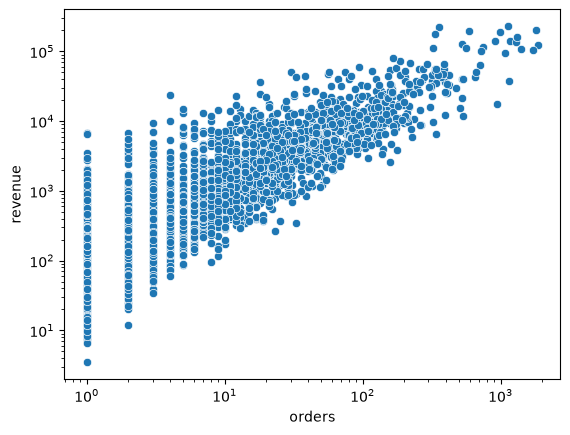

In [63]:
sns.scatterplot(
    data=revenue_df,
    x="orders",
    y="revenue"
)

plt.xscale("log")
plt.yscale("log")

plt.savefig(
        plots_dir / 'log_scale.png',
        dpi = 300,
        bbox_inches = 'tight'
        )

plt.show()

In [64]:
revenue_df.write_database(
    table_name="analytics.volume_order_revenue",
    connection=engine,
    if_table_exists="replace"
)

-1

In [65]:
pl.read_database(
        query = """
        select table_name,
        column_name
        from information_schema.columns
        where table_name in('order_items', 'products');
        """, connection = engine
        )

table_name,column_name
str,str
"""products""","""product_weight_g"""
"""products""","""product_length_cm"""
"""products""","""product_height_cm"""
"""products""","""product_width_cm"""
"""order_items""","""price"""
"""order_items""","""order_item_id"""
"""products""","""product_name_lenght"""
"""products""","""product_description_lenght"""
"""order_items""","""shipping_limit_date"""


In [66]:
category_df = pl.read_database(
        query = """
        select oi.seller_id,
        c.product_category_name_english,
        sum(oi.price) as revenue,
        count(*) as items_sold,
        count(distinct oi.order_id) as orders 
        from clean.order_items oi 
        join clean.products p 
        on oi.product_id = p.product_id 
        join clean.categories c 
        on p.product_category_name = c.product_category_name
        group by oi.seller_id, c.product_category_name_english;
        """, connection = engine
        )

In [67]:
category_df.sort('revenue', descending = True).head()

seller_id,product_category_name_english,revenue,items_sold,orders
str,str,f64,i64,i64
"""4869f7a5dfa277a7dca6462dcf3b52b2""","""watches_gifts""","201,071.73","1,002",981
"""fa1c13f2614d7b5c4749cbc52fecda94""","""watches_gifts""","192,092.74",579,579
"""7c67e1448b00f6e969d365cea6b010ab""","""office_furniture""","172,959.66","1,233",891
"""7e93a43ef30c4f03f38b393420bc753a""","""watches_gifts""","169,768.06",314,311
"""53243585a1d6dc2643021fd1853d8905""","""computers""","166,871.75",153,146


In [68]:
category_summary_df = (
        category_df.group_by('product_category_name_english')
        .agg(
            pl.sum('revenue').alias('revenue'),
            pl.n_unique('seller_id').alias('sellers'),
            pl.sum('items_sold').alias('items_sold'),
            pl.sum('orders').alias('orders'))
        .sort('revenue', descending=True)
        )

In [69]:
category_summary_df.head()

product_category_name_english,revenue,sellers,items_sold,orders
str,f64,u32,i64,i64
"""health_beauty""","1,258,681.34",492,"9,670","8,863"
"""watches_gifts""","1,205,005.68",101,"5,991","5,660"
"""bed_bath_table""","1,036,988.68",196,"11,115","9,627"
"""sports_leisure""","988,048.97",481,"8,641","7,772"
"""computers_accessories""","911,954.32",287,"7,827","6,763"


In [70]:
category_summary_df = category_summary_df.with_columns(
        (
            pl.col('revenue') /
            pl.col('revenue').sum()
            * 100.00
            ).alias('revenue_pct')
        )

In [71]:
category_summary_df = category_summary_df.with_columns(
        pl.col('revenue_pct')
        .cum_sum()
        .alias('cumulative_revenue_pct')
        )

In [72]:
category_summary_df.head(int(category_summary_df.height * 0.20))

product_category_name_english,revenue,sellers,items_sold,orders,revenue_pct,cumulative_revenue_pct
str,f64,u32,i64,i64,f64,f64
"""health_beauty""","1,258,681.34",492,"9,670","8,863",9.38,9.38
"""watches_gifts""","1,205,005.68",101,"5,991","5,660",8.98,18.37
"""bed_bath_table""","1,036,988.68",196,"11,115","9,627",7.73,26.10
"""sports_leisure""","988,048.97",481,"8,641","7,772",7.37,33.47
"""computers_accessories""","911,954.32",287,"7,827","6,763",6.80,40.27
"""furniture_decor""","729,762.49",370,"8,334","6,529",5.44,45.71
"""cool_stuff""","635,290.85",267,"3,796","3,636",4.74,50.44
"""housewares""","632,248.66",468,"6,964","5,932",4.71,55.16
"""auto""","592,720.11",383,"4,235","3,921",4.42,59.58


In [73]:
health_beauty_df = category_df.filter(
        pl.col('product_category_name_english')
        == 'health_beauty'
        ).sort('revenue', descending = True)

In [75]:
health_beauty_df = health_beauty_df.with_columns(
        (
            pl.col('revenue') /
            pl.col('revenue').sum()
            * 100)
        .alias('revenue_pct')
        )

health_beauty_df = health_beauty_df.with_columns(
        (
            pl.col('revenue_pct')
            .cum_sum())
        .alias('cumulative_revenue_pct')
        )

In [76]:
health_beauty_df.head(int(health_beauty_df.height * 0.01))

seller_id,product_category_name_english,revenue,items_sold,orders,revenue_pct,cumulative_revenue_pct
str,str,f64,i64,i64,f64,f64
"""edb1ef5e36e0c8cd84eb3c9b003e486d""","""health_beauty""","79,284.55",175,166,6.30,6.30
"""ccc4bbb5f32a6ab2b7066a4130f114e3""","""health_beauty""","72,471.73",187,182,5.76,12.06
"""f7ba60f8c3f99e7ee4042fdef03b70c4""","""health_beauty""","65,817.00",201,192,5.23,17.29
"""cc419e0650a3c5ba77189a1882b7556a""","""health_beauty""","63,920.01","1,091","1,056",5.08,22.36


In [77]:
watches_gifts_df = category_df.filter(
        pl.col('product_category_name_english')
        == 'watches_gifts'
        ).sort('revenue', descending = True)


In [78]:
watches_gifts_df = watches_gifts_df.with_columns(
        (
            pl.col('revenue') /
            pl.col('revenue').sum()
            * 100)
        .alias('revenue_pct')
        )

watches_gifts_df = watches_gifts_df.with_columns(
        (
            pl.col('revenue_pct')
            .cum_sum())
        .alias('cumulative_revenue_pct')
        )


In [83]:
watches_gifts_df.head(int(watches_gifts_df.height * 0.01))

seller_id,product_category_name_english,revenue,items_sold,orders,revenue_pct,cumulative_revenue_pct
str,str,f64,i64,i64,f64,f64
"""4869f7a5dfa277a7dca6462dcf3b52b2""","""watches_gifts""","201,071.73","1,002",981,16.69,16.69


In [84]:
computers_df = category_df.filter(
        pl.col('product_category_name_english')
        == 'computers'
        ).sort('revenue', descending = True)

In [85]:
computers_df = computers_df.with_columns(
        (
            pl.col('revenue') /
            pl.col('revenue').sum()
            * 100)
        .alias('revenue_pct')
        )

computers_df = computers_df.with_columns(
        (
            pl.col('revenue_pct')
            .cum_sum())
        .alias('cumulative_revenue_pct')
        )

In [89]:
computers_df

seller_id,product_category_name_english,revenue,items_sold,orders,revenue_pct,cumulative_revenue_pct
str,str,f64,i64,i64,f64,f64
"""53243585a1d6dc2643021fd1853d8905""","""computers""","166,871.75",153,146,74.84,74.84
"""7681ef142fd2c19048da7430856b5588""","""computers""","28,198.92",41,26,12.65,87.49
"""a00824eb9093d40e589b940ec45c4eb0""","""computers""","9,399.97",3,3,4.22,91.71
"""80ceebb4ee9b31afb6c6a916a574a1e2""","""computers""","6,729.00",1,1,3.02,94.72
"""c72de06d72748d1a0dfb2125be43ba63""","""computers""","4,590.00",1,1,2.06,96.78
"""585175ec331ea177fa47199e39a6170a""","""computers""","3,549.00",1,1,1.59,98.37
"""403aa86912527d730337ffcb0fb096ab""","""computers""","2,199.99",1,1,0.99,99.36
"""0873d9f8f36123f8d910f4760e788cfb""","""computers""","1,390.00",1,1,0.62,99.98
"""1c40343cc5d18c2d8248ac2f3366de34""","""computers""",34.50,1,1,0.02,100.00


In [90]:
import numpy as np

def gini(values):
    values = np.array(values, dtype=np.float64)

    if np.amin(values) < 0:
        values = values - np.amin(values)

    values = np.sort(values)

    n = len(values)
    index = np.arange(1, n + 1)

    return (
        np.sum((2 * index - n - 1) * values)
        / (n * np.sum(values))
    )

In [92]:
for name, df in {
    "health_beauty": health_beauty_df,
    "watches_gifts": watches_gifts_df,
    "computers": computers_df
}.items():

    g = gini(df["revenue"])

    print(f"{name}: {g:.4f}")

health_beauty: 0.8270
watches_gifts: 0.8546
computers: 0.7628
